### Backtest report: price vs. portfolio value

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.config import load_config
from src.strategy.strategy import OrderFlowConfirmedStrategy
from src.backtest.backtest_leveraged_order_flow import LeveragedOrderFlowBacktester
from src.backtest.plotting import plot_leveraged_backtest

ACCOUNT_BALANCE_USD = 1000.0

config = load_config()
strategy_cfg = config["strategy"]
strategy = OrderFlowConfirmedStrategy(
    threshold_pct=strategy_cfg["threshold_pct"],
    lookback_minutes=strategy_cfg["lookback_minutes"],
)

backtester = LeveragedOrderFlowBacktester(
    symbol=config["ingestion"]["symbol"],
    strategy=strategy,
    trade_amount_usd=strategy_cfg["trade_amount_usd"],
    leverage=5.0,
    initial_capital=ACCOUNT_BALANCE_USD,
)

summary = backtester.run()
for key, value in summary.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

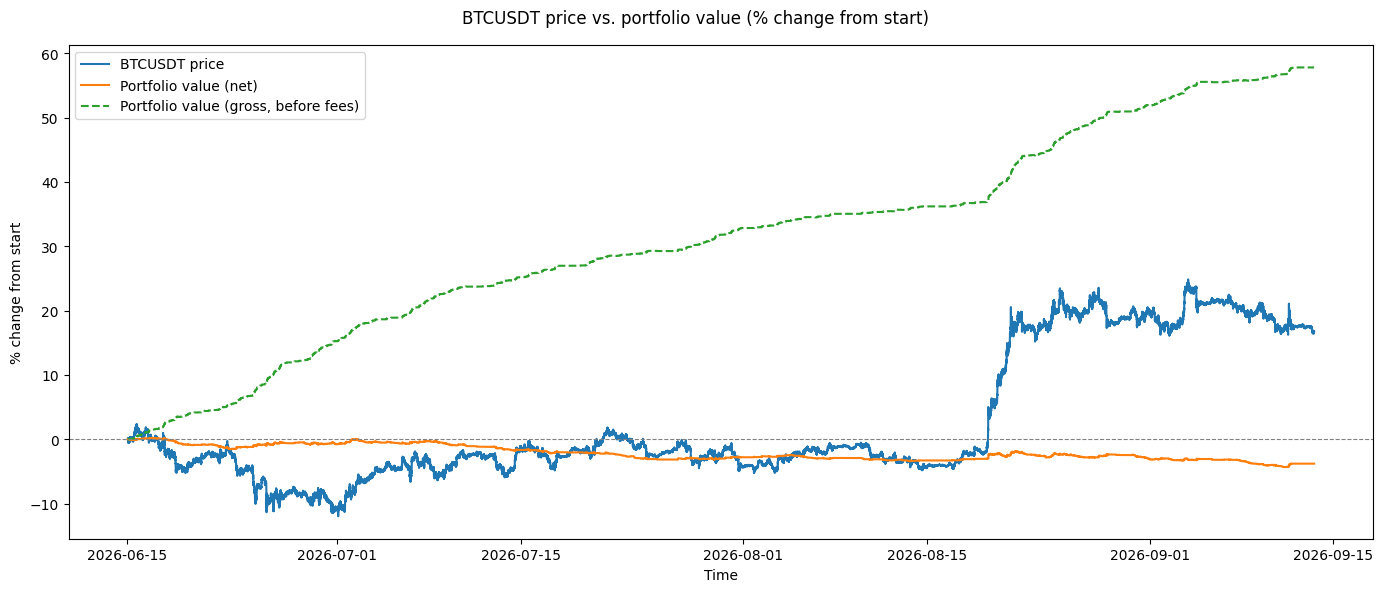

In [ ]:
fig = plot_leveraged_backtest(backtester, symbol=config["ingestion"]["symbol"].upper())